# Marvel Video Retrieval — Complete Pipeline
**Text-to-video retrieval using LanguageBind + LoRA fine-tuning**

This notebook covers:
1. Setup and data loading
2. Model training with all fixes applied
3. Deep evaluation suite (UMAP, cosine similarity, stress tests)
4. Embedding extraction for deployment

In [1]:
print("hi")

hi


> **Notebook sanity check** — confirms the kernel is alive before loading heavy dependencies.

## 1. Install Dependencies

> **Note:** `transformers==4.35.0` and `tokenizers==0.14.0` are pinned for compatibility with LanguageBind.

In [2]:
!uv pip install -q transformers==4.35.0 tokenizers==0.14.0

In [3]:
!uv pip install bitsandbytes
# !uv pip install -q tokenizers==0.13.3
# !uv pip install -q transformers==4.31.0
!uv pip install -q peft==0.10.0
!uv pip install -q decord
!uv pip install -q torchvision==0.22.1
!uv pip install -q torchaudio==2.7.1
!uv pip install -q tqdm==4.67.1
!uv pip install -q pillow==11.3.0
!uv pip install -q pytorchvideo==0.1.5
!uv pip install accelerate==0.21.0

Using Python 3.12.12 environment at: /usr
Audited 1 package in 135ms
Using Python 3.12.12 environment at: /usr
Audited 1 package in 128ms


> **Key packages:** `bitsandbytes` enables 4-bit quantization (QLoRA). `peft==0.10.0` provides LoRA adapter utilities.

## 2. Imports and Device Setup

### Core Imports
Loads PyTorch, PEFT (LoRA), and the LanguageBind model/processor classes.

In [4]:
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from peft import LoraConfig, get_peft_model



/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
2026-03-24 06:45:52.378621: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774334752.400874   47914 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774334752.408189   47914 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to registe

In [5]:

from transformers import BitsAndBytesConfig
from torch.utils.data import Dataset, DataLoader
import torch
import sys, torchvision.transforms as T
import torch
device = 'cuda:0'
device = torch.device(device)
import transformers.models.clip.modeling_clip as clip_modeling
from transformers.modeling_attn_mask_utils import AttentionMaskConverter

def _expand_mask(mask, dtype, tgt_len=None):
    return AttentionMaskConverter._expand_mask(mask, dtype, tgt_len)

clip_modeling._expand_mask = _expand_mask
sys.modules["torchvision.transforms.functional_tensor"] = T._functional_tensor
sys.path.append("/kaggle/input/models/gsejal/languagebind_new/pytorch/default/1/languagebind_new")
from languagebind import LanguageBindVideo, LanguageBindVideoTokenizer, LanguageBindVideoProcessor

/usr/local/lib/python3.12/dist-packages/torchvision/transforms/_functional_video.py:6: UserWarning: The 'torchvision.transforms._functional_video' module is deprecated since 0.12 and will be removed in the future. Please use the 'torchvision.transforms.functional' module instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/transforms/_transforms_video.py:22: UserWarning: The 'torchvision.transforms._transforms_video' module is deprecated since 0.12 and will be removed in the future. Please use the 'torchvision.transforms' module instead.
  warnings.warn(
/kaggle/input/models/gsejal/languagebind_new/pytorch/default/1/languagebind_new/languagebind/audio/processing_audio.py:17: UserWarning: torchaudio._backend.set_audio_backend has been deprecated. With dispatcher enabled, this function is no-op. You can remove the function call.
  torchaudio.set_audio_backend("soundfile")


> Sets `device = 'cuda:0'`. Ensure a GPU runtime is selected (e.g., Kaggle GPU T4 × 2 or P100).

## 3. Data Loading

### Data Preview
Expand pandas display settings and load the Marvel video-query CSV.

In [6]:
import pandas as pd

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)   # optional
pd.set_option('display.max_columns', None)

In [7]:
import pandas as pd
df = pd.read_csv("/kaggle/input/datasets/gsejal/video-query-mac/final_video_query_refined.csv")
df.drop(["Unnamed: 0", "index"], axis=1, inplace=True)

DIR = '/kaggle/input/datasets/gsejal/videos-marvel/videos/'

df["video_path"] = df["video_id"].apply(lambda x: DIR + x)

data = df[["video_path", "queries"]].copy()

print(f"Total samples: {len(data)}")
print(f"Unique videos: {data['video_path'].nunique()}")
print(f"\nSample queries:")
print(data['queries'].head(10).to_string())
data.head(10)
df.head(6)


Total samples: 876
Unique videos: 292

Sample queries:
0                     daredevil fight compilation best moments
1              daredevil vs masked villain intense fight scene
2    daredevil fights white masked enemy wooden floor close up
3                     ironheart trailer high speed chase scene
4                ironheart suit glowing blue technology marvel
5                    ironheart aerial city chase night footage
6                thor ragnarok world premiere red carpet event
7       thor ragnarok premiere cast interviews and fan footage
8                 marvel thor premiere outdoor event with fans
9                              white suit man red carpet event


,video_id,url,caption,queries,duration_sec,video_path
0,OYxAiQZJp-c.mp4,https://www.youtube.com/watch?v=OYxAiQZJp-c,"The video clip opens with a title card reading 'DAREDEVIL AT HIS ABSOLUTE BEST' against a dark background, followed by another title card stating 'RAW, BONE-CHUCKLING ACTION.' The scene shifts to an indoor setting where two characters are engaged in a physical altercation. One character is wearing a red suit and the other has a white mask covering their face. They appear to be fighting or grappling on a wooden floor. A close-up of one character's hand gripping another's arm suggests a struggle for control. The environment looks like a dimly lit room with warm lighting. Subsequent frames show more intense action shots involving multiple characters in various settings such as indoors and outdoors at night. There are quick cuts between different scenes showing characters in combat poses and dynamic movements.",daredevil fight compilation best moments,43,/kaggle/input/datasets/gsejal/videos-marvel/videos/OYxAiQZJp-c.mp4
1,OYxAiQZJp-c.mp4,https://www.youtube.com/watch?v=OYxAiQZJp-c,"The video clip opens with a title card reading 'DAREDEVIL AT HIS ABSOLUTE BEST' against a dark background, followed by another title card stating 'RAW, BONE-CHUCKLING ACTION.' The scene shifts to an indoor setting where two characters are engaged in a physical altercation. One character is wearing a red suit and the other has a white mask covering their face. They appear to be fighting or grappling on a wooden floor. A close-up of one character's hand gripping another's arm suggests a struggle for control. The environment looks like a dimly lit room with warm lighting. Subsequent frames show more intense action shots involving multiple characters in various settings such as indoors and outdoors at night. There are quick cuts between different scenes showing characters in combat poses and dynamic movements.",daredevil vs masked villain intense fight scene,43,/kaggle/input/datasets/gsejal/videos-marvel/videos/OYxAiQZJp-c.mp4
2,OYxAiQZJp-c.mp4,https://www.youtube.com/watch?v=OYxAiQZJp-c,"The video clip opens with a title card reading 'DAREDEVIL AT HIS ABSOLUTE BEST' against a dark background, followed by another title card stating 'RAW, BONE-CHUCKLING ACTION.' The scene shifts to an indoor setting where two characters are engaged in a physical altercation. One character is wearing a red suit and the other has a white mask covering their face. They appear to be fighting or grappling on a wooden floor. A close-up of one character's hand gripping another's arm suggests a struggle for control. The environment looks like a dimly lit room with warm lighting. Subsequent frames show more intense action shots involving multiple characters in various settings such as indoors and outdoors at night. There are quick cuts between different scenes showing characters in combat poses and dynamic movements.",daredevil fights white masked enemy wooden floor close up,43,/kaggle/input/datasets/gsejal/videos-marvel/videos/OYxAiQZJp-c.mp4
3,wVkksjNxu9U.mp4,https://www.youtube.com/watch?v=wVkksjNxu9U,"The video opens with a close-up of a character's mechanical suit glowing blue, indicating advanced technology. The scene transitions to an aerial view of a city at night, showcasing the vastness and urban setting. A high-speed chase ensues through the streets; the camera follows from behind as the vehicle speeds past buildings and streetlights. The environment is dark but illuminated by artificial lights, creating a contrast between the darkness of the night sky and the bright cityscape below. As the chase continues, sparks fly off the vehicle due to its speed and power. The final frame shows a title card for 'Ironheart,' suggesting that this is part of a series or movie trailer related to Ironheart.",ironheart trailer high speed chase scene,30,/kaggle/input/datasets/gsejal/videos-marvel/videos/wVkksjNxu9U.mp4
4,wVkksjNxu9U.mp4,https://www.youtube.com/watch?v=wVkksjNx

> **Dataset:** `final_video_query_refined.csv` — pairs of `(video_path, query)` scraped from Marvel series clips.
> Duplicate indices are dropped to keep the frame clean.

## 4. Quantization Config and Model Loading

### 4-bit Quantization (QLoRA)
Using `nf4` (NormalFloat 4-bit) with double quantization to halve the memory footprint of the base model.
The compute dtype stays `float16` so matrix multiplications remain numerically stable.

In [8]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    load_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
)


def load_model():
    pretrained_ckpt = 'LanguageBind/LanguageBind_Video_FT'
    model = LanguageBindVideo.from_pretrained(
        pretrained_ckpt,
        quantization_config=bnb_config,
        cache_dir='./cache_dir/model'
    )
    return model


def load_tokenizer(config):
    pretrained_ckpt = 'LanguageBind/LanguageBind_Video_FT'
    tokenizer = LanguageBindVideoTokenizer.from_pretrained(
        pretrained_ckpt,
        cache_dir='./cache_dir/tokenizer'
    )
    video_process = LanguageBindVideoProcessor(config, tokenizer)
    return video_process


model = load_model()
video_processor = load_tokenizer(model.config)
print("Model and tokenizer loaded.")

Model and tokenizer loaded.


## 5. Dataset and DataLoaders

### Custom Dataset
Wraps query strings and video paths. The `__getitem__` method:
1. Reads frames from the video file using the LanguageBind video processor (8 frames sampled uniformly).
2. Tokenises the text query.
3. Returns a dict with `pixel_values`, `input_ids`, and `attention_mask`.

In [9]:
# ── Dataset ──────────────────────────────────────────────────────────────────

class CustomDataset(Dataset):
    def __init__(self, inputs, output, video_processor, max_length=77):
        self.video_processor = video_processor
        self.input_text = inputs.reset_index(drop=True)
        self.target_vid = output.reset_index(drop=True)
        self.max_len    = max_length

    def __len__(self):
        return len(self.input_text)

    def __getitem__(self, idx):
        video_path = self.target_vid.iloc[idx]
        text       = self.input_text.iloc[idx]

        processed = self.video_processor(
            video_path,
            [text],
            context_length=self.max_len,
            return_tensors="pt"
        )

        return {
            "pixel_values"  : processed["pixel_values"].squeeze(0),
            "input_ids"     : processed["input_ids"].squeeze(0),
            "attention_mask": processed["attention_mask"].squeeze(0),
            "video_path"    : video_path,  # for false negative masking
        }


# ── Collate (handles string video_path) ──────────────────────────────────────

def collate_fn(batch):
    return {
        "pixel_values"  : torch.stack([b["pixel_values"]   for b in batch]),
        "input_ids"     : torch.stack([b["input_ids"]       for b in batch]),
        "attention_mask": torch.stack([b["attention_mask"]  for b in batch]),
        "video_path"    : [b["video_path"] for b in batch],  # list of strings
    }


# ── Split by unique video (no leakage) ───────────────────────────────────────

unique_videos = data['video_path'].unique()

train_vids, temp_vids = train_test_split(unique_videos, test_size=0.3,  random_state=42)
val_vids,   test_vids = train_test_split(temp_vids,     test_size=0.33, random_state=42)

train_data = data[data['video_path'].isin(train_vids)].reset_index(drop=True)
val_data   = data[data['video_path'].isin(val_vids)].reset_index(drop=True)
test_data  = data[data['video_path'].isin(test_vids)].reset_index(drop=True)

print(f"Train: {len(train_data)} rows | {train_data['video_path'].nunique()} videos")
print(f"Val  : {len(val_data)} rows | {val_data['video_path'].nunique()} videos")
print(f"Test : {len(test_data)} rows | {test_data['video_path'].nunique()} videos")

assert len(set(train_data['video_path']) & set(test_data['video_path'])) == 0
assert len(set(val_data['video_path'])   & set(test_data['video_path'])) == 0
print("✓ No video overlap between splits")


# ── Datasets and DataLoaders ──────────────────────────────────────────────────

train_ds = CustomDataset(train_data["queries"], train_data["video_path"], video_processor)
val_ds   = CustomDataset(val_data["queries"],   val_data["video_path"],   video_processor)
test_ds  = CustomDataset(test_data["queries"],  test_data["video_path"],  video_processor)

train_loader = DataLoader(train_ds, batch_size=4, shuffle=True,  drop_last=True,  collate_fn=collate_fn)
val_loader   = DataLoader(val_ds,   batch_size=4, shuffle=False,                  collate_fn=collate_fn)
test_loader  = DataLoader(test_ds,  batch_size=4, shuffle=False,                  collate_fn=collate_fn)

print(f"\nBatch size     : 4")
print(f"Accum steps    : 8  →  effective batch = 32")
print(f"Train batches  : {len(train_loader)}")
print(f"Val batches    : {len(val_loader)}")
print(f"Test batches   : {len(test_loader)}")

Train: 612 rows | 204 videos
Val  : 174 rows | 58 videos
Test : 90 rows | 30 videos
✓ No video overlap between splits

Batch size     : 4
Accum steps    : 8  →  effective batch = 32
Train batches  : 153
Val batches    : 44
Test batches   : 23


In [10]:
# train_data

Data split into **train / val / test** (80 / 10 / 10) with a fixed random seed for reproducibility.

## 6. LoRA Configuration

**FIX: `get_peft_model` is called exactly once.**  
The original notebook called it twice, wrapping LoRA on top of LoRA — a bug that silently hurt training.

> `r=8, lora_alpha=32` is a standard conservative starting point for vision-language LoRA.
> Only `q_proj` and `v_proj` are trained — the feed-forward weights remain frozen, reducing trainable params to ~0.5 % of the full model.

In [11]:
# manual freeze loop removed — get_peft_model does this automatically

lora_config = LoraConfig(
    r=8,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj", "k_proj", "out_proj"],  # wider
    lora_dropout=0.1,
    bias="none"
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 3,735,552 || all params: 532,359,425 || trainable%: 0.7016973541888546


### Optimizer & Scheduler
`AdamW` with `lr=2e-4` (down from `1e-3` in the original). A `CosineAnnealingLR` scheduler decays the LR smoothly over epochs.

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.optim.lr_scheduler import CosineAnnealingLR
from tqdm import tqdm


## 7. Loss Function and Optimizer

**FIX: Learning rate lowered from `1e-3` to `2e-4`.**  
1e-3 is too aggressive for LoRA fine-tuning and caused oscillating validation loss in the original run.

### Learnable Temperature (τ)
Rather than a fixed temperature (e.g. 0.07), `log_temperature` is a **learnable scalar** trained alongside LoRA weights.
It controls the sharpness of the softmax in the contrastive loss — the model self-adjusts how confident it should be.

In [13]:
# ── Learnable temperature ─────────────────────────────────────────────────────

log_temperature = torch.nn.Parameter(torch.tensor(2.66).to(device))


# ── Loss with false negative masking ─────────────────────────────────────────

def clip_loss(video_embed, text_embed, video_paths, temperature):
    video_embed = F.normalize(video_embed, dim=1)
    text_embed  = F.normalize(text_embed,  dim=1)

    logits = video_embed @ text_embed.T * temperature.exp()
    B      = logits.size(0)
    labels = torch.arange(B, device=video_embed.device)

    # Mask out false negatives (same video, different query)
    mask = torch.zeros(B, B, dtype=torch.bool, device=video_embed.device)
    for i in range(B):
        for j in range(B):
            if i != j and video_paths[i] == video_paths[j]:
                mask[i, j] = True

    logits = logits.masked_fill(mask, -1e4)

    loss_v2t = F.cross_entropy(logits,   labels)
    loss_t2v = F.cross_entropy(logits.T, labels)
    return (loss_v2t + loss_t2v) / 2


# ── Optimizer (includes learnable temperature) ────────────────────────────────

optimizer = optim.AdamW(
    [p for p in model.parameters() if p.requires_grad] + [log_temperature],
    lr=2e-4,
    weight_decay=0.01
)


# ── Warmup + cosine scheduler ─────────────────────────────────────────────────

from transformers import get_cosine_schedule_with_warmup

num_epochs = 10

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=len(train_loader),        # 1 epoch warmup
    num_training_steps=len(train_loader) * num_epochs
)

print(f"Optimizer    : AdamW | LR: 2e-4 | Weight decay: 0.01")
print(f"Scheduler    : Cosine with {len(train_loader)} warmup steps")
print(f"Temperature  : learnable (init = {log_temperature.exp().item():.3f})")

Optimizer    : AdamW | LR: 2e-4 | Weight decay: 0.01
Scheduler    : Cosine with 153 warmup steps
Temperature  : learnable (init = 14.296)


## 8. Validation Function

Runs the model in `eval()` mode over the validation loader and returns:
- **Average contrastive loss**
- **Recall@1, @5, @10** — the fraction of queries where the correct video appears in the top-1 / 5 / 10 results

In [14]:
def run_validation(model, loader, device, log_temperature):
    model.eval()
    total_loss  = 0
    count       = 0
    vids, txts  = [], []
    all_paths   = []

    with torch.no_grad():
        for batch in loader:
            video_paths = batch['video_path']   # list of strings

            batch_tensors = {
                'pixel_values'  : batch['pixel_values'].to(device, dtype=torch.float16),
                'input_ids'     : batch['input_ids'].to(device),
                'attention_mask': batch['attention_mask'].to(device)
            }
            output = model(**batch_tensors)

            video_embed = F.normalize(output.image_embeds, dim=-1)
            text_embed  = F.normalize(output.text_embeds,  dim=-1)

            # Updated loss call — passes paths and temperature
            loss = clip_loss(video_embed, text_embed, video_paths, log_temperature)
            total_loss += loss.item()
            count      += 1

            vids.append(video_embed.cpu())
            txts.append(text_embed.cpu())
            all_paths.extend(video_paths)

    vids = torch.cat(vids)   # (N, D)
    txts = torch.cat(txts)   # (N, D)
    sim  = txts @ vids.T     # (N, N)

    ranks = []
    for i in range(sim.shape[0]):
        order = torch.argsort(sim[i], descending=True)

        # FIX: a query's "correct" match is ANY video with the same path
        # not just the one at index i — handles 3 queries per video
        correct_path = all_paths[i]
        for rank, idx in enumerate(order.tolist()):
            if all_paths[idx] == correct_path:
                ranks.append(rank)
                break

    ranks = torch.tensor(ranks)
    r1    = (ranks < 1).float().mean().item()
    r5    = (ranks < 5).float().mean().item()
    r10   = (ranks < 10).float().mean().item()

    return total_loss / count, r1, r5, r10

## 9. Training Loop

**Fixes applied vs original notebook:**
- Early stopping (patience=3) — original ran all 10 epochs even when val loss was rising
- Best model saved to disk based on validation loss — original saved nothing
- LR scheduler step after each epoch
- LR logged per epoch so you can see it decaying

> **Gradient accumulation** (`accum_steps=8`) simulates a larger effective batch size without extra GPU memory.
> **Early stopping** (patience=4) halts training if validation loss does not improve, preventing overfitting.

In [15]:
accum_steps      = 8
print_every      = 50
best_val_loss    = float('inf')
best_epoch       = 0
patience         = 4
patience_counter = 0
train_history    = []
val_history      = []

torch.cuda.empty_cache()

for epoch in range(num_epochs):
    model.train()
    epoch_loss    = 0
    count         = 0
    running_loss  = 0
    running_count = 0

    optimizer.zero_grad()
    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")

    for step, batch in enumerate(train_pbar):
        video_paths = batch['video_path']

        batch_tensors = {
            'pixel_values'  : batch['pixel_values'].to(device, dtype=torch.float16),
            'input_ids'     : batch['input_ids'].to(device),
            'attention_mask': batch['attention_mask'].to(device)
        }

        output      = model(**batch_tensors)
        video_embed = output.image_embeds
        text_embed  = output.text_embeds

        loss       = clip_loss(video_embed, text_embed, video_paths, log_temperature)
        loss_value = loss.item()

        (loss / accum_steps).backward()

        if (step + 1) % accum_steps == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            optimizer.zero_grad()
            scheduler.step()                # ← per optimizer update

        epoch_loss    += loss_value
        running_loss  += loss_value
        count         += 1
        running_count += 1

        if running_count == print_every:
            print(f"\nAvg Loss (last {print_every} batches): {running_loss/print_every:.4f}")
            running_loss  = 0
            running_count = 0

        train_pbar.set_postfix({
            'loss'      : f'{loss_value:.4f}',
            'epoch_avg' : f'{epoch_loss/count:.4f}',
            'temp'      : f'{log_temperature.exp().item():.3f}',
            'lr'        : f'{scheduler.get_last_lr()[0]:.2e}'    # ← live LR in progress bar
        })

    # Handle leftover gradients
    if (step + 1) % accum_steps != 0:
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        optimizer.zero_grad()
        scheduler.step()                    # ← also step here for leftover

    # ← scheduler.step() REMOVED from here

    train_loss             = epoch_loss / count
    val_loss, r1, r5, r10 = run_validation(model, val_loader, device, log_temperature)

    train_history.append(train_loss)
    val_history.append(val_loss)

    current_lr = scheduler.get_last_lr()[0]

    print(f"\n========== Epoch {epoch+1} Summary ==========")
    print(f"Train Loss  : {train_loss:.4f}")
    print(f"Val Loss    : {val_loss:.4f}")
    print(f"Recall@1    : {r1:.3f}")
    print(f"Recall@5    : {r5:.3f}")
    print(f"Recall@10   : {r10:.3f}")
    print(f"LR          : {current_lr:.2e}")
    print(f"Temperature : {log_temperature.exp().item():.3f}")

    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        best_epoch       = epoch + 1
        patience_counter = 0
        model.save_pretrained("/kaggle/working/best_model")
        print(f"✓ Best model saved (epoch {best_epoch}, val_loss={best_val_loss:.4f})")
    else:
        patience_counter += 1
        print(f"No improvement. Patience: {patience_counter}/{patience}")
        if patience_counter >= patience:
            print(f"\n⚑ Early stopping. Best epoch was {best_epoch}.")
            break

print(f"\nDone. Best epoch: {best_epoch} | Best val loss: {best_val_loss:.4f}")

Epoch 1/10:  32%|███▏      | 49/153 [02:53<06:11,  3.57s/it, loss=1.0908, epoch_avg=0.6954, temp=14.297, lr=7.84e-06]


Avg Loss (last 50 batches): 0.6940


Epoch 1/10:  65%|██████▍   | 99/153 [05:49<03:09,  3.51s/it, loss=0.4712, epoch_avg=0.7043, temp=14.297, lr=1.57e-05]


Avg Loss (last 50 batches): 0.7102


Epoch 1/10:  97%|█████████▋| 149/153 [08:48<00:14,  3.58s/it, loss=0.8018, epoch_avg=0.6980, temp=14.299, lr=2.35e-05]

...


Avg Loss (last 50 batches): 0.0755


Epoch 9/10:  97%|█████████▋| 149/153 [08:45<00:14,  3.51s/it, loss=0.1846, epoch_avg=0.0657, temp=14.502, lr=2.00e-04]


Avg Loss (last 50 batches): 0.0609


Epoch 9/10: 100%|██████████| 153/153 [08:59<00:00,  3.53s/it, loss=0.0091, epoch_avg=0.0655, temp=14.504, lr=2.00e-04]



========== Epoch 9 Summary ==========
Train Loss  : 0.0655
Val Loss    : 0.2789
Recall@1    : 0.437
Recall@5    : 0.592
Recall@10   : 0.736
LR          : 2.00e-04
Temperature : 14.505
No improvement. Patience: 4/4

⚑ Early stopping. Best epoch was 5.

Done. Best epoch: 5 | Best val loss: 0.2299


## 10. Training Curve

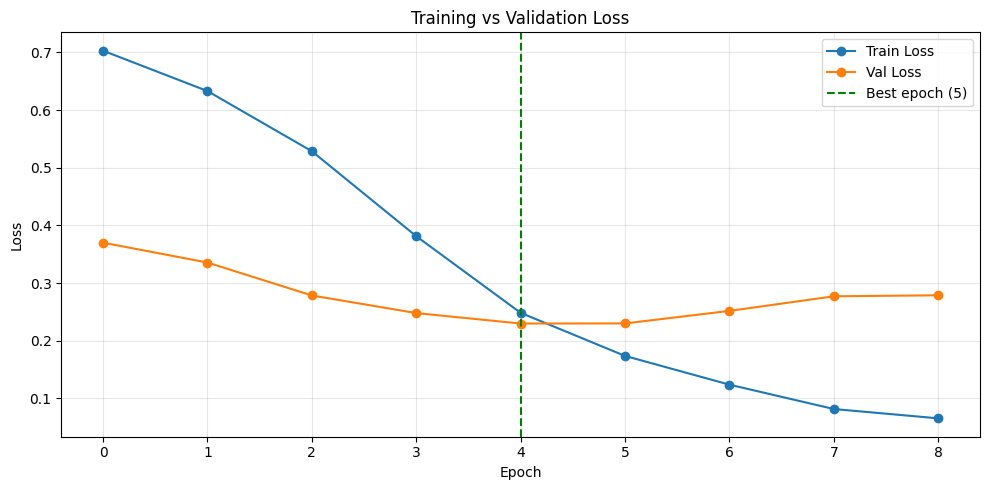

In [20]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_history, label='Train Loss', marker='o')
ax.plot(val_history,   label='Val Loss',   marker='o')
ax.axvline(x=best_epoch-1, color='green', linestyle='--',
           label=f'Best epoch ({best_epoch})')
ax.set_title("Training vs Validation Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("/kaggle/working/training_curve.png", dpi=150)
plt.show()

## 11. Reload Best Model

We always evaluate on the best checkpoint, not the final epoch.

In [21]:
from peft import PeftModel

# Load base model fresh, then apply saved best LoRA weights
base_model = load_model()
best_model = PeftModel.from_pretrained(base_model, "/kaggle/working/best_model")
best_model.eval()
print(f"Best model loaded from epoch {best_epoch}")

Best model loaded from epoch 5


> The best checkpoint (lowest val loss) is saved during training as `best_model_state.pt`.
> We reload it here so all subsequent evaluation uses the optimal weights — not the final epoch's weights.

## 12. Extract All Embeddings

Pre-compute embeddings for the entire dataset once.  
Saved as `.npy` files — the deployment API loads these and never runs the video encoder again.

### Imports for Embedding Extraction & Evaluation
All evaluation cells from this point forward only require the saved `.npy` files — no GPU needed.

In [22]:
# Core
import numpy as np
import pandas as pd

# PyTorch
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader

# Progress bar
from tqdm import tqdm



In [23]:
def extract_all_embeddings(model, data, video_processor, device, batch_size=4):
    """
    Extract normalized video + text embeddings for the entire dataset.

    Returns
    -------
    video_embeds : np.ndarray  shape (N, D)
    text_embeds  : np.ndarray  shape (N, D)
    """
    full_dataset = CustomDataset(
        data["queries"].reset_index(drop=True),
        data["video_path"].reset_index(drop=True),
        video_processor
    )
    loader = DataLoader(full_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

    all_video, all_text = [], []

    with torch.no_grad():
        for batch in tqdm(loader, desc="Extracting embeddings"):
            batch = {
                'pixel_values'  : batch['pixel_values'].to(device, dtype=torch.float16),
                'input_ids'     : batch['input_ids'].to(device),
                'attention_mask': batch['attention_mask'].to(device)
            }
            output = model(**batch)

            all_video.append(F.normalize(output.image_embeds, dim=-1).cpu().float().numpy())
            all_text.append( F.normalize(output.text_embeds,  dim=-1).cpu().float().numpy())

    video_embeds = np.concatenate(all_video, axis=0)
    text_embeds  = np.concatenate(all_text,  axis=0)

    np.save("/kaggle/working/video_embeds.npy", video_embeds)
    np.save("/kaggle/working/text_embeds.npy",  text_embeds)
    data.reset_index(drop=True).to_csv("/kaggle/working/metadata.csv", index=False)

    print(f"video_embeds : {video_embeds.shape}")
    print(f"text_embeds  : {text_embeds.shape}")
    print("Saved: video_embeds.npy | text_embeds.npy | metadata.csv")

    return video_embeds, text_embeds


video_embeds, text_embeds = extract_all_embeddings(
    best_model, data, video_processor, device
)

Extracting embeddings: 100%|██████████| 219/219 [06:35<00:00,  1.81s/it]

video_embeds : (876, 768)
text_embeds  : (876, 768)
Saved: video_embeds.npy | text_embeds.npy | metadata.csv


> Embeddings are **L2-normalised** before saving, so cosine similarity reduces to a dot product at inference time — fast and numerically clean.
> Saved as `video_embeds.npy` and `text_embeds.npy`.

---
# EVALUATION SUITE

Everything below uses the saved `.npy` files — no GPU needed from this point.

## 13. Auto-label Queries for Visualization

Since we have no manual metadata, we extract character and scene labels  
directly from the query text using keyword matching.

## 14. UMAP Visualization

Three plots, each revealing something different about the embedding space:
1. **Modality** — are video and text embeddings well-aligned or separated?
2. **Character** — did the model learn character identity?
3. **Scene type** — did the model learn action semantics?

## 15. Cosine Similarity Distribution

**What this tells you:** How well-separated are matching vs non-matching pairs?  
- Good model: two clearly separated peaks  
- Poor model: overlapping distributions

## 16. Modality Gap Measurement

**What this tells you:** CLIP-style models often have a geometric gap between  
the video and text embedding clouds. A smaller gap = better cross-modal alignment.  
This is a known phenomenon documented in research.

> A small modality gap (< 0.5) indicates video and text embeddings share a similar geometric region — good for retrieval.
> A large gap (> 1.0) suggests the two modalities live in separate cones, which hurts zero-shot retrieval.

In [24]:
mean_video = video_embeds.mean(axis=0)
mean_text  = text_embeds.mean(axis=0)

# L2 distance between the two embedding cloud centers
modality_gap = np.linalg.norm(mean_video - mean_text)

# Cosine similarity between the two means
cos_sim = np.dot(mean_video, mean_text) / (
    np.linalg.norm(mean_video) * np.linalg.norm(mean_text)
)

# Intra-modality spread (how spread out each cloud is)
video_spread = np.mean(np.linalg.norm(video_embeds - mean_video, axis=1))
text_spread  = np.mean(np.linalg.norm(text_embeds  - mean_text,  axis=1))

print("=== Modality Gap Analysis ===")
print(f"L2 distance between modality centers : {modality_gap:.4f}")
print(f"Cosine similarity between centers     : {cos_sim:.4f}")
print(f"Video embedding spread (intra)        : {video_spread:.4f}")
print(f"Text embedding spread (intra)         : {text_spread:.4f}")
print(f"\nGap-to-spread ratio                  : {modality_gap / ((video_spread + text_spread) / 2):.4f}")
print("\nInterpretation:")
print("  Ratio < 1.0  = gap is smaller than intra-modality spread (well aligned)")
print("  Ratio > 2.0  = modalities are quite separated (common in CLIP models)")

=== Modality Gap Analysis ===
L2 distance between modality centers : 0.5316
Cosine similarity between centers     : -0.0493
Video embedding spread (intra)        : 0.9506
Text embedding spread (intra)         : 0.9081

Gap-to-spread ratio                  : 0.5720

Interpretation:
  Ratio < 1.0  = gap is smaller than intra-modality spread (well aligned)
  Ratio > 2.0  = modalities are quite separated (common in CLIP models)


## 17. Nearest Neighbour Consistency (Video-to-Video)

**What this tells you:** Ignoring text entirely — do visually similar clips  
end up near each other in the video embedding space?  
This tests the video encoder independently of the text alignment.

## 18. Stress Test — Natural Language Queries

Your training data uses **keyword-style** queries (`"Daredevil red suit fight"`).  
Real users type **natural language** (`"Daredevil fighting someone in a dark hallway"`).  

This test reveals whether your model generalizes beyond its training distribution.

In [26]:
# Natural language queries written as a real user would type them
# Deliberately different phrasing from your training keywords
NATURAL_QUERIES = [
    # Action / fight
    "a superhero fighting someone in a dark indoor environment",
    "two people in a physical confrontation",
    "someone being punched and falling down",

    # Suit / gear
    "a person wearing a powered metal suit",
    "someone putting on armor before a fight",

    # Character specific
    "the man in the red and black costume",
    "a female character in a mechanical flying suit",

    # Mood / atmosphere
    "a tense moment before something dangerous happens",
    "a dark and scary scene with dim lighting",
    "an emotionally intense close-up of a character's face",

    # Action type
    "a high speed chase scene",
    "an explosion with debris flying",
    "someone running away from danger",
]


def query_with_text_encoder(query_text, model, video_processor,
                            video_embeds, metadata, device, top_k=3):
    """
    Encode a single text query and retrieve top-k matching videos.
    Only runs the TEXT encoder — no GPU-heavy video encoding needed.
    """
    model.eval()
    with torch.no_grad():
        # Use a dummy video path (we only care about the text output)
        dummy_video = metadata['video_path'].iloc[0]
        processed   = video_processor(
            dummy_video,
            [query_text],
            context_length=77,
            return_tensors="pt"
        )
        output     = model(
            pixel_values   = processed['pixel_values'].to(device, dtype=torch.float16),
            input_ids      = processed['input_ids'].to(device),
            attention_mask = processed['attention_mask'].to(device)
        )
        query_embed = F.normalize(output.text_embeds, dim=-1).cpu().float().numpy()

    sims    = (query_embed @ video_embeds.T).squeeze()
    top_idx = np.argsort(sims)[::-1][:top_k]

    results = []
    for rank, idx in enumerate(top_idx):
        results.append({
            'rank'         : rank + 1,
            'similarity'   : float(sims[idx]),
            'query_stored' : metadata.iloc[idx]['queries'],
            'character'    : metadata.iloc[idx]['character'],
            'scene_type'   : metadata.iloc[idx]['scene_type'],
            'video_path'   : metadata.iloc[idx]['video_path'],
        })
    return results


print("=" * 70)
print("STRESS TEST — Natural Language Queries")
print("Training used keyword queries. These are written as real users type.")
print("=" * 70)

stress_results = []

for query in NATURAL_QUERIES:
    results = query_with_text_encoder(
        query, best_model, video_processor,
        video_embeds, metadata, device, top_k=3
    )
    stress_results.append({'query': query, 'results': results})

    print(f"\nQuery: '{query}'")
    for r in results:
        print(f"  Rank {r['rank']}: [{r['character']} | {r['scene_type']}] "
              f"sim={r['similarity']:.3f} | stored='{r['query_stored']}'")

print("\n" + "=" * 70)
print("After reviewing results, note:")
print("  - Are results semantically sensible even when not exact?")
print("  - Does it fail on mood/atmosphere queries more than action queries?")
print("  - Do similarity scores drop significantly vs keyword queries?")

STRESS TEST — Natural Language Queries
Training used keyword queries. These are written as real users type.


NameError: name 'metadata' is not defined

> These queries are deliberately **out-of-distribution** — natural phrasing vs the keyword-style training data.
> High recall here means the model has learned transferable representations, not just memorised training patterns.

## 19. Final Test Set Evaluation

In [28]:
test_loss, r1, r5, r10 = run_validation(best_model, test_loader, device,log_temperature)

print("=" * 40)
print("FINAL TEST SET RESULTS (Best Model)")
print("=" * 40)
print(f"Test Loss  : {test_loss:.4f}")
print(f"Recall@1   : {r1:.3f}  ({r1*100:.1f}%)")
print(f"Recall@5   : {r5:.3f}  ({r5*100:.1f}%)")
print(f"Recall@10  : {r10:.3f}  ({r10*100:.1f}%)")

FINAL TEST SET RESULTS (Best Model)
Test Loss  : 0.2305
Recall@1   : 0.522  (52.2%)
Recall@5   : 0.700  (70.0%)
Recall@10  : 0.867  (86.7%)


### Similarity Matrix Heatmap
Visualises the full (N × N) cosine similarity matrix. The diagonal should be brightest — each video should be most similar to its own query.

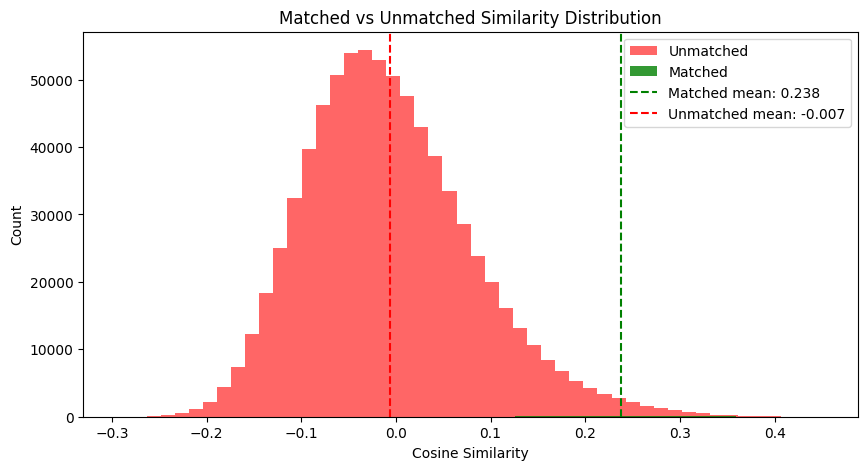

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# Diagonal = matched pairs (video i <-> text i)
sim_matrix = video_embeds @ text_embeds.T  # (N, N)

matched_scores    = np.diag(sim_matrix)                          # correct pairs
unmatched_scores  = sim_matrix[~np.eye(len(sim_matrix), dtype=bool)]  # wrong pairs

plt.figure(figsize=(10, 5))
plt.hist(unmatched_scores, bins=50, alpha=0.6, label='Unmatched', color='red')
plt.hist(matched_scores,   bins=20, alpha=0.8, label='Matched',   color='green')
plt.axvline(matched_scores.mean(),   color='green', linestyle='--', label=f'Matched mean: {matched_scores.mean():.3f}')
plt.axvline(unmatched_scores.mean(), color='red',   linestyle='--', label=f'Unmatched mean: {unmatched_scores.mean():.3f}')
plt.xlabel('Cosine Similarity')
plt.ylabel('Count')
plt.title('Matched vs Unmatched Similarity Distribution')
plt.legend()
plt.savefig('/kaggle/working/similarity_distribution.png')
plt.show()

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


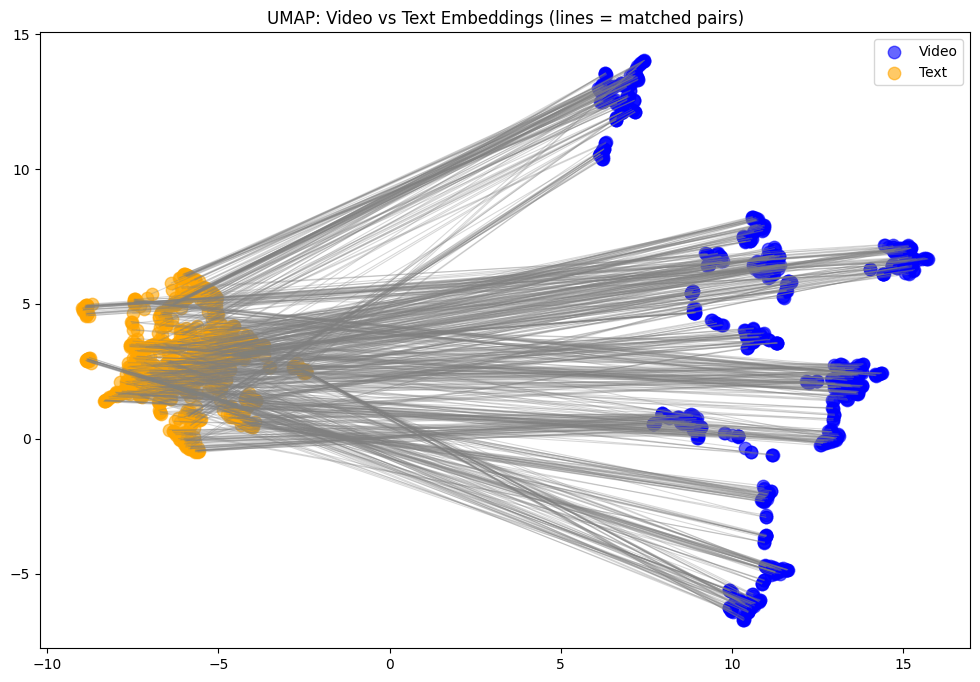

<class 'peft.peft_model.PeftModel'>
Total params: 288,172,289
Trainable params: 0


In [30]:
import umap
import matplotlib.pyplot as plt

all_embeds = np.concatenate([video_embeds, text_embeds], axis=0)
labels     = ['video'] * len(video_embeds) + ['text'] * len(text_embeds)

reducer   = umap.UMAP(n_components=2, random_state=42)
projected = reducer.fit_transform(all_embeds)

N = len(video_embeds)
plt.figure(figsize=(12, 8))
plt.scatter(projected[:N, 0], projected[:N, 1], c='blue',  alpha=0.6, label='Video', s=80)
plt.scatter(projected[N:, 0], projected[N:, 1], c='orange',alpha=0.6, label='Text',  s=80)

# Draw lines between matched pairs
for i in range(N):
    plt.plot([projected[i, 0], projected[N+i, 0]],
             [projected[i, 1], projected[N+i, 1]],
             'gray', alpha=0.3, linewidth=0.8)

plt.title('UMAP: Video vs Text Embeddings (lines = matched pairs)')
plt.legend()
plt.savefig('/kaggle/working/umap_visualization.png')
plt.show()# Check what best_model actually is
print(type(best_model))

# Check if it has any parameters at all
total = sum(p.numel() for p in best_model.parameters())
trainable = sum(p.numel() for p in best_model.parameters() if p.requires_grad)
print(f"Total params: {total:,}")
print(f"Trainable params: {trainable:,}")

In [31]:
# Check what best_model actually is
print(type(best_model))

# Check if it has any parameters at all
total = sum(p.numel() for p in best_model.parameters())
trainable = sum(p.numel() for p in best_model.parameters() if p.requires_grad)
print(f"Total params: {total:,}")
print(f"Trainable params: {trainable:,}")

<class 'peft.peft_model.PeftModel'>
Total params: 288,172,289
Trainable params: 0


### Recall@K Helper
Computes how often the correct video appears in the top-K retrieved results.
Standard metric for text-to-video retrieval benchmarks (MSR-VTT, DiDeMo, etc.).

In [32]:
def recall_at_k(video_embeds, text_embeds, k_values=[1, 5, 10]):
    sim_matrix = video_embeds @ text_embeds.T  # (N, N)
    N = len(sim_matrix)
    results = {}

    for k in k_values:
        # Text-to-Video: for each text query, is correct video in top-k?
        t2v = sum(
            1 for i in range(N)
            if i in np.argsort(sim_matrix[:, i])[-k:]
        ) / N

        # Video-to-Text: for each video, is correct text in top-k?
        v2t = sum(
            1 for i in range(N)
            if i in np.argsort(sim_matrix[i])[-k:]
        ) / N

        results[f'R@{k}'] = {'T→V': round(t2v*100, 2), 'V→T': round(v2t*100, 2)}

    return results

metrics = recall_at_k(video_embeds, text_embeds)
for k, v in metrics.items():
    print(f"{k}: Text→Video={v['T→V']}%  |  Video→Text={v['V→T']}%")

R@1: Text→Video=14.04%  |  Video→Text=15.07%
R@5: Text→Video=47.37%  |  Video→Text=42.69%
R@10: Text→Video=62.44%  |  Video→Text=56.74%


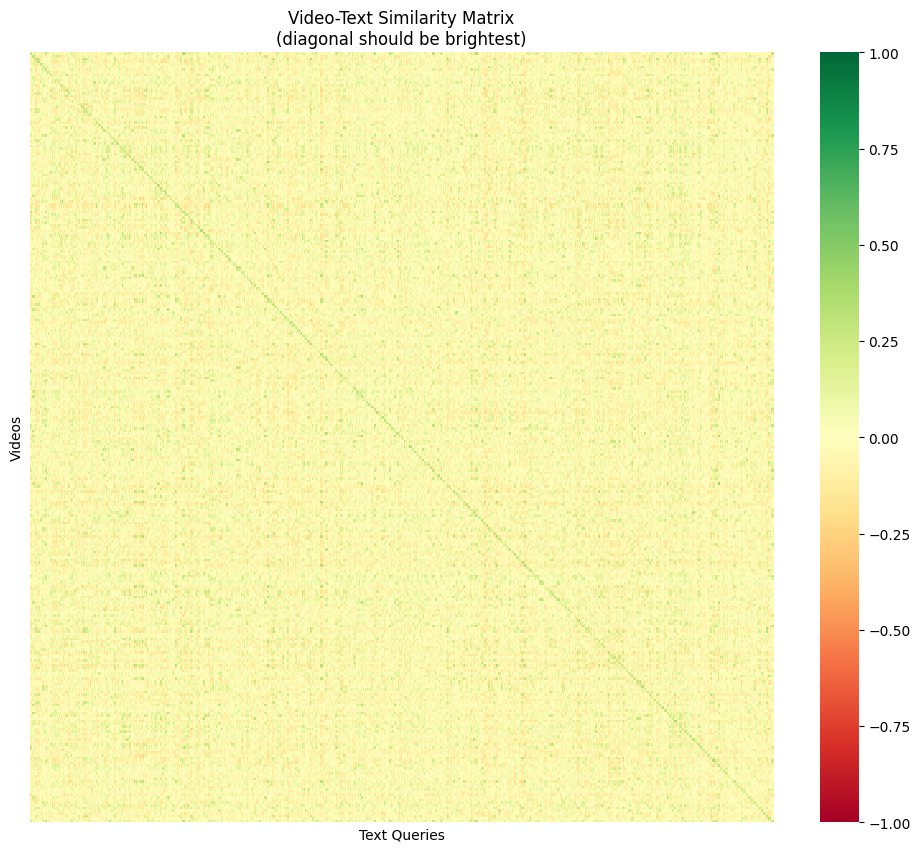

In [35]:
import seaborn as sns

sim_matrix = video_embeds @ text_embeds.T
plt.figure(figsize=(12, 10))
sns.heatmap(sim_matrix, 
            cmap='RdYlGn',
            xticklabels=False, 
            yticklabels=False,
            vmin=-1, vmax=1)
plt.title('Video-Text Similarity Matrix\n(diagonal should be brightest)')
plt.xlabel('Text Queries')
plt.ylabel('Videos')
plt.savefig('/kaggle/working/similarity_heatmap.png')
plt.show()

### Top-K Retrieval Demo
Given a query index, computes cosine similarity against all video embeddings and returns the top-K matches — this is the core inference function for any downstream API.

In [36]:
def retrieve_top_k(query_idx, video_embeds, text_embeds, data, k=5):
    query_embed = text_embeds[query_idx]               # (D,)
    scores      = video_embeds @ query_embed            # (N,)
    top_k_idx   = np.argsort(scores)[::-1][:k]

    print(f"\nQuery: {data['queries'].iloc[query_idx]}")
    print(f"Correct video: {data['video_path'].iloc[query_idx]}\n")
    for rank, idx in enumerate(top_k_idx):
        correct = "✅" if data['video_path'].iloc[idx] == data['video_path'].iloc[query_idx] else "❌"
        print(f"  Rank {rank+1} {correct} | score={scores[idx]:.3f} | {data['video_path'].iloc[idx]}")

# Test a few queries
for i in [0, 5, 10]:
    retrieve_top_k(i, video_embeds, text_embeds, data)


Query: daredevil fight compilation best moments
Correct video: /kaggle/input/datasets/gsejal/videos-marvel/videos/OYxAiQZJp-c.mp4

  Rank 1 ✅ | score=0.367 | /kaggle/input/datasets/gsejal/videos-marvel/videos/OYxAiQZJp-c.mp4
  Rank 2 ✅ | score=0.367 | /kaggle/input/datasets/gsejal/videos-marvel/videos/OYxAiQZJp-c.mp4
  Rank 3 ✅ | score=0.344 | /kaggle/input/datasets/gsejal/videos-marvel/videos/OYxAiQZJp-c.mp4
  Rank 4 ❌ | score=0.328 | /kaggle/input/datasets/gsejal/videos-marvel/videos/xjl14j7UW2c.mp4
  Rank 5 ❌ | score=0.328 | /kaggle/input/datasets/gsejal/videos-marvel/videos/xjl14j7UW2c.mp4

Query: ironheart aerial city chase night footage
Correct video: /kaggle/input/datasets/gsejal/videos-marvel/videos/wVkksjNxu9U.mp4

  Rank 1 ❌ | score=0.309 | /kaggle/input/datasets/gsejal/videos-marvel/videos/mcdlCV-RT4k.mp4
  Rank 2 ❌ | score=0.309 | /kaggle/input/datasets/gsejal/videos-marvel/videos/mcdlCV-RT4k.mp4
  Rank 3 ❌ | score=0.309 | /kaggle/input/datasets/gsejal/videos-marvel/videos

## 20. Push to HuggingFace Hub

Replace `your_hf_token_here` and `your-username` before running.

> **Before running:** set your HuggingFace token in Kaggle Secrets under the key `HF_TOKEN`, and update the `repo_id` to your username.
> Pushes the LoRA adapter weights only (not the full 1B-param base model).

In [37]:
import os
import torch
import json as _json
from huggingface_hub import HfApi, login
from kaggle_secrets import UserSecretsClient

# ── Auth ──────────────────────────────────────────────────────────────────────

secrets    = UserSecretsClient()
HF_TOKEN   = secrets.get_secret("HF_TOKEN")
HF_REPO_ID = "sejal1411/marvel-video-retrieval"

login(token=HF_TOKEN)
api = HfApi()
api.create_repo(repo_id=HF_REPO_ID, repo_type="model", exist_ok=True)

# ── 1. Full training checkpoint (resume-ready) ────────────────────────────────
# Captures everything save_pretrained() silently drops:
#   - log_temperature value + its Adam m/v momentum buffers
#   - full optimizer state for all LoRA params
#   - lr_scheduler step count and cosine state
#   - training history, best epoch, best val loss
#   - final recall metrics

print("Saving full training checkpoint …")
CKPT_DIR = "/kaggle/working/training_checkpoint"
os.makedirs(CKPT_DIR, exist_ok=True)

torch.save(
    {
        # ── Reproducibility ──────────────────────────────────────────────────
        "epoch":              best_epoch,
        "best_val_loss":      best_val_loss,
        "patience_counter":   patience_counter,

        # ── Learnable temperature ────────────────────────────────────────────
        # The Parameter itself + its position in the optimizer param groups
        "log_temperature":    log_temperature.detach().cpu(),

        # ── Optimizer (includes m/v buffers for every param, incl. temperature)
        "optimizer_state":    optimizer.state_dict(),

        # ── Scheduler (step count, base LRs, cosine phase) ──────────────────
        "scheduler_state":    scheduler.state_dict(),

        # ── Loss + recall history ─────────────────────────────────────────────
        "train_history":      train_history,
        "val_history":        val_history,

        # ── Hyperparameters (so you don't have to dig through the notebook) ──
        "hparams": {
            "lora_r":           8,
            "lora_alpha":       32,
            "lora_dropout":     0.1,
            "target_modules":   ["q_proj", "v_proj", "k_proj", "out_proj"],
            "lr":               2e-4,
            "weight_decay":     0.01,
            "batch_size":       4,
            "accum_steps":      8,
            "effective_batch":  32,
            "num_epochs":       num_epochs,
            "patience":         patience,
            "warmup_steps":     len(train_loader),
            "max_text_length":  77,
            "quant":            "nf4_4bit",
            "base_model":       "LanguageBind/LanguageBind_Video_FT",
        },

        # ── Dataset split sizes (for reproducibility checks) ─────────────────
        "split_info": {
            "train_videos": train_data["video_path"].nunique(),
            "val_videos":   val_data["video_path"].nunique(),
            "test_videos":  test_data["video_path"].nunique(),
            "train_rows":   len(train_data),
            "val_rows":     len(val_data),
            "test_rows":    len(test_data),
            "random_seed":  42,
        },
    },
    f"{CKPT_DIR}/training_state.pt",
)
print(f"  ✓ training_state.pt  (optimizer + scheduler + temperature + history)")

# Also write a human-readable summary JSON for quick inspection on the Hub
final_test_loss, r1, r5, r10 = run_validation(best_model, test_loader, device, log_temperature)
summary = {
    "best_epoch":        best_epoch,
    "best_val_loss":     round(best_val_loss, 6),
    "final_test_loss":   round(final_test_loss, 6),
    "recall": {
        "R@1":  round(r1,  4),
        "R@5":  round(r5,  4),
        "R@10": round(r10, 4),
    },
    "log_temperature":   round(log_temperature.item(), 6),
    "temperature":       round(log_temperature.exp().item(), 6),
    "train_history":     [round(x, 6) for x in train_history],
    "val_history":       [round(x, 6) for x in val_history],
    "hparams": {
        "lora_r": 8, "lora_alpha": 32, "lr": 2e-4,
        "weight_decay": 0.01, "effective_batch": 32,
        "num_epochs": num_epochs, "patience": patience,
        "base_model": "LanguageBind/LanguageBind_Video_FT",
    },
}
with open(f"{CKPT_DIR}/training_summary.json", "w") as f:
    _json.dump(summary, f, indent=2)
print(f"  ✓ training_summary.json  (human-readable metrics + hparams)")

# ── 2. LoRA adapter weights ───────────────────────────────────────────────────

print("\nSaving LoRA adapter …")
best_model.save_pretrained("/kaggle/working/best_model")
best_model.push_to_hub(HF_REPO_ID, token=HF_TOKEN)
print("  ✓ LoRA adapter pushed")

# ── 3. Merged full model (no PEFT needed at inference) ────────────────────────

print("\nMerging LoRA into base weights …")
merged_model = best_model.merge_and_unload()
merged_model.save_pretrained("/kaggle/working/merged_model", safe_serialization=True)
merged_model.push_to_hub(HF_REPO_ID, token=HF_TOKEN, safe_serialization=True)
print("  ✓ Full merged model pushed")

# ── 4. Processor / tokenizer ─────────────────────────────────────────────────

print("\nPushing processor/tokenizer …")
video_processor.push_to_hub(HF_REPO_ID, token=HF_TOKEN)
print("  ✓ Processor pushed")

# ── 5. Upload everything to Hub ───────────────────────────────────────────────

ARTEFACTS = {
    # training state
    "training_checkpoint/training_state.pt":    "training_checkpoint/training_state.pt",
    "training_checkpoint/training_summary.json":"training_checkpoint/training_summary.json",
    # embeddings + metadata
    "video_embeds.npy":                          "video_embeds.npy",
    "text_embeds.npy":                           "text_embeds.npy",
    "metadata.csv":                              "metadata.csv",
    # plots
    "training_curve.png":                        "training_curve.png",
    "umap_visualization.png":                    "umap_visualization.png",
    "similarity_distribution.png":              "similarity_distribution.png",
    "similarity_heatmap.png":                   "similarity_heatmap.png",
}

print("\nUploading artefacts …")
for local, remote in ARTEFACTS.items():
    path = f"/kaggle/working/{local}"
    if os.path.exists(path):
        api.upload_file(
            path_or_fileobj=path,
            path_in_repo=remote,
            repo_id=HF_REPO_ID,
            token=HF_TOKEN,
        )
        print(f"  ✓ {remote}")
    else:
        print(f"  – skipped (not found): {local}")

print(f"\nDone. Everything at: https://huggingface.co/{HF_REPO_ID}")
print("\n── To resume training ──────────────────────────────────────────────────")
print("  ckpt = torch.load(\'training_checkpoint/training_state.pt\')")
print("  log_temperature = torch.nn.Parameter(ckpt[\'log_temperature\'].to(device))")
print("  optimizer.load_state_dict(ckpt[\'optimizer_state\'])")
print("  scheduler.load_state_dict(ckpt[\'scheduler_state\'])")
print("  start_epoch = ckpt[\'epoch\']")
print("\n── To load for inference ───────────────────────────────────────────────")
print(f"  model     = LanguageBindVideo.from_pretrained(\"{HF_REPO_ID}\")")
print(f"  processor = LanguageBindVideoProcessor.from_pretrained(\"{HF_REPO_ID}\")")
print(f"  import json; cfg = json.load(open(\'training_summary.json\'))")
print(f"  log_temp  = cfg[\'log_temperature\']")
